# Correlazioni dinamiche del trimero anello — dal circuito alla validazione

Notebook principale della fase circuito, mirror per $N=3$ di `correlazioni_dimero_esplorazione.ipynb`.
Qui **non si riderivano** le simmetrie (già fatto in `correlazioni_trimero_anello_simmetria.ipynb`
e in `simmetrie_correlatori_trimero_anello.tex`): si costruisce il circuito Hadamard test con
l'ancilla, lo si esegue davvero, e lo si valida — contro il calcolo classico esatto (statevector)
e contro il rumore statistico a shot finiti.

Tutta la logica pesante è già scritta e verificata negli script `.py` del progetto; qui la
richiamiamo per import invece di riscriverla, per tenere il notebook leggibile:

- `circuito_correlazioni_trimero_anello.py` — stato fondamentale, costruzione del circuito, lettura
  dell'ancilla;
- `validate_circuito_correlazioni.py` — riferimento classico esatto (`scipy.linalg.expm`);
- `trotter_trimero_anello.py` — il blocco $U(t)$ (Trotter a due livelli annidati);
- `trimer_ring_exact.py` — l'Hamiltoniana.

Punto di lavoro: $J=1,\,J'=0.4,\,b=b_c=2.4,\,D=0.15$ (Opzione B).

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator

from trimer_ring_exact import trimer_hamiltonian_dm
from circuito_correlazioni_trimero_anello import (
    ground_state, build_correlator_circuit, correlator_from_circuit,
)
from validate_circuito_correlazioni import classical_exact

np.set_printoptions(precision=4, suppress=True)
J, Jp, b, D = 1.0, 0.4, 2.4, 0.15
N = 200  # passi di Trotter per U(t)
print("Setup pronto.")

Setup pronto.


## 1. Ground state e Hamiltoniana

In [2]:
H = trimer_hamiltonian_dm(J, Jp, b, "B", D).to_matrix()
psi0, E = ground_state(J, Jp, b, D)
print(f"Punto di lavoro: J={J}, J'={Jp}, b={b}, D={D} (Opzione B)")
print(f"E0={E[0]:.6f}   gap E1-E0={E[1]-E[0]:.6f}")
print(f"psi0 (fase reale fissata): {psi0}")

Punto di lavoro: J=1.0, J'=0.4, b=2.4, D=0.15 (Opzione B)
E0=-5.534370   gap E1-E0=0.254700
psi0 (fase reale fissata): [-0.    +0.j  0.0283+0.j -0.0094+0.j  0.5131+0.j -0.0094+0.j -0.5131+0.j
 -0.    +0.j  0.6874+0.j]


## 2. Il circuito con l'ancilla

Hadamard test a 4 qubit (3 di registro + 1 ancilla): $H$ sull'ancilla, controlled-$W=\sigma_j^\beta$
prima di $U(t)$, $U(t)$ **non** controllato (Trotter a due livelli, da `trotter_trimero_anello.py`),
anti-controlled-$V=\sigma_i^\alpha$ dopo. Rotazione finale $H$ (Re) o $R_x(\pi/2)$ (Im) + misura
dell'ancilla. Derivazione completa in `circuito_correlazioni_trimero_anello_spiegato.tex`.

Disegno schematico per $C_{12}^{yy}(t)$, con $N=2$ passi solo per leggibilità (la misura vera usa
$N=200$).

In [3]:
qc_re = build_correlator_circuit(1, "y", 2, "y", t=2.0, N=2, J=J, Jp=Jp, b=b, D=D,
                                  part="re", psi0=psi0, measure=True)
fig = qc_re.draw("mpl", style="iqp", fold=-1)
fig.suptitle("Parte reale di $C_{12}^{yy}(t)$: rotazione H, poi misura", fontsize=12, y=1.02)
plt.show()

## 3. Validazione: statevector vs classico esatto

Riferimento classico via `scipy.linalg.expm` (indipendente dalla formula spettrale, per non reintrodurre la classe di bug già trovata nel dimero).

In [4]:
cases = [
    (1, "y", 1, "y", 1.3),
    (3, "y", 3, "y", 1.3),
    (1, "y", 3, "y", 1.3),
    (3, "x", 3, "z", 2.7),   # atteso ~0 per ogni t (Corollario zero-sito3)
    (1, "y", 2, "y", 2.7),
    (2, "y", 1, "y", 2.7),   # deve coincidere con la precedente (eta_y eta_y=+1)
]

print(f"{'correlatore':<12}{'t':>5}   {'esatto classico':>20}   {'circuito (N=200)':>20}   {'|residuo|':>10}")
residui = []
for (i, al, j, be, t) in cases:
    c_ref = classical_exact(i, al, j, be, t, J, Jp, b, D, psi0, H)
    c_circ = correlator_from_circuit(i, al, j, be, t, N, J, Jp, b, D, psi0)
    resid = abs(c_ref - c_circ)
    residui.append(resid)
    label = f"C_{i}{j}^{al}{be}"
    print(f"{label:<12}{t:>5.1f}   {c_ref.real:+.4f}{c_ref.imag:+.4f}i"
          f"      {c_circ.real:+.4f}{c_circ.imag:+.4f}i        {resid:.2e}")

print(f"\nresiduo medio={np.mean(residui):.2e}  max={np.max(residui):.2e}  "
      f"(atteso: solo errore di Trotter a N={N})")

correlatore     t        esatto classico       circuito (N=200)    |residuo|
C_11^yy       1.3   +0.4521-0.1560i      +0.4522-0.1553i        7.08e-04
C_33^yy       1.3   +0.1727-0.0062i      +0.1727-0.0069i        6.19e-04
C_13^yy       1.3   +0.3443-0.0163i      +0.3441-0.0167i        4.05e-04
C_33^xz       2.7   +0.0000+0.0000i      +0.0011+0.0000i        1.14e-03
C_12^yy       2.7   -0.3574+0.4338i      -0.3565+0.4337i        9.61e-04
C_21^yy       2.7   -0.3574+0.4338i      -0.3564+0.4338i        9.87e-04

residuo medio=8.03e-04  max=1.14e-03  (atteso: solo errore di Trotter a N=200)


**Discussione.** Il quarto caso ($C_{33}^{xz}$) conferma via circuito lo zero strutturale del
sito 3 — residuo $\sim10^{-3}$, compatibile con solo Trotter, non un residuo sistematico. Il quinto
e il sesto verificano la relazione di simmetria $C_{12}^{yy}(t)=C_{21}^{yy}(t)$
($\eta_y\eta_y=+1$): concordano fra loro e con l'esatto entro lo stesso errore.

## 4. Convergenza in $N$ (errore di Trotter)

Convergenza per C_11^yy(t=1.3):

  N=  10: |errore| = 1.857e-02
  N=  20: |errore| = 7.892e-03  (rapporto vs precedente: 2.35)
  N=  40: |errore| = 3.687e-03  (rapporto vs precedente: 2.14)
  N=  80: |errore| = 1.794e-03  (rapporto vs precedente: 2.05)
  N= 160: |errore| = 8.872e-04  (rapporto vs precedente: 2.02)
  N= 320: |errore| = 4.414e-04  (rapporto vs precedente: 2.01)


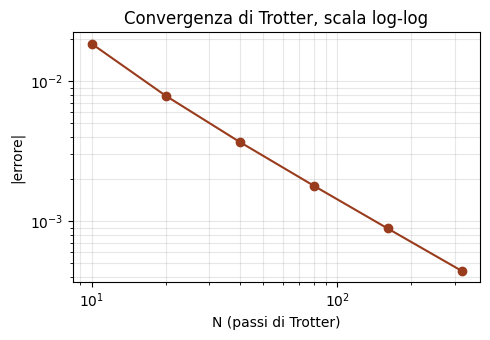


atteso: rapporto -> 2.0 raddoppiando N (Trotter 1o ordine, errore ~ O(1/N) sull'ampiezza)


In [5]:
i, al, j, be, t = 1, "y", 1, "y", 1.3
c_ref = classical_exact(i, al, j, be, t, J, Jp, b, D, psi0, H)
N_values = [10, 20, 40, 80, 160, 320]
errori = []
prev = None
print(f"Convergenza per C_{i}{j}^{al}{be}(t={t}):\n")
for Nt in N_values:
    c_circ = correlator_from_circuit(i, al, j, be, t, Nt, J, Jp, b, D, psi0)
    err = abs(c_ref - c_circ)
    errori.append(err)
    ratio = f"  (rapporto vs precedente: {prev/err:.2f})" if prev else ""
    print(f"  N={Nt:4d}: |errore| = {err:.3e}{ratio}")
    prev = err

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.loglog(N_values, errori, "o-", color="#993C1D")
ax.set_xlabel("N (passi di Trotter)")
ax.set_ylabel("|errore|")
ax.set_title("Convergenza di Trotter, scala log-log")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()
print("\natteso: rapporto -> 2.0 raddoppiando N (Trotter 1o ordine, errore ~ O(1/N) sull'ampiezza)")

## 5. Validazione a shot finiti

Esecuzione vera con `AerSimulator`, rumore statistico incluso — confronto fra errore di Trotter e errore statistico allo stesso punto di lavoro.

In [6]:
BACKEND = AerSimulator()

def shot_estimate(i, alpha, j, beta, t, Nt, shots, part, seed=None):
    qc = build_correlator_circuit(i, alpha, j, beta, t, Nt, J, Jp, b, D, part,
                                   psi0=psi0, measure=True)
    qc_t = transpile(qc, BACKEND)
    result = BACKEND.run(qc_t, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()
    n0, n1 = counts.get("0", 0), counts.get("1", 0)
    return (n0 - n1) / shots

shots = 8192
i, al, j, be, t = 1, "y", 1, "y", 1.3
re_sh = shot_estimate(i, al, j, be, t, N, shots, "re", seed=42)
im_sh = shot_estimate(i, al, j, be, t, N, shots, "im", seed=43)
c_shots = re_sh + 1j * im_sh
c_sv = correlator_from_circuit(i, al, j, be, t, N, J, Jp, b, D, psi0)
c_ref = classical_exact(i, al, j, be, t, J, Jp, b, D, psi0, H)

err_trotter = abs(c_sv - c_ref)
err_statistico = abs(c_shots - c_sv)
print(f"C_{i}{j}^{al}{be}(t={t}):")
print(f"  esatto classico     = {c_ref.real:+.4f}{c_ref.imag:+.4f}i")
print(f"  statevector (N={N}) = {c_sv.real:+.4f}{c_sv.imag:+.4f}i   |errore Trotter|   = {err_trotter:.2e}")
print(f"  shots ({shots})       = {c_shots.real:+.4f}{c_shots.imag:+.4f}i   |errore statistico| = {err_statistico:.2e}")
print(f"\nsoglia statistica nel caso peggiore, 1/sqrt({shots}) = {1/np.sqrt(shots):.4f}")
print(f"rapporto (statistico/Trotter): {err_statistico/err_trotter:.1f}x  "
      "-> qui l'errore statistico domina, opposto al regime R1 del dimero")

C_11^yy(t=1.3):
  esatto classico     = +0.4521-0.1560i
  statevector (N=200) = +0.4522-0.1553i   |errore Trotter|   = 7.08e-04
  shots (8192)       = +0.4592-0.1389i   |errore statistico| = 1.79e-02

soglia statistica nel caso peggiore, 1/sqrt(8192) = 0.0110
rapporto (statistico/Trotter): 25.2x  -> qui l'errore statistico domina, opposto al regime R1 del dimero


**Discussione.** Analisi più estesa (convergenza vs $N_\text{shots}$ su molte ripetizioni,
scan completo dell'errore su tutte le combinazioni) è in `validate_shot_noise_trimero_anello.py`
e in `scan81_trimero_anello.py` — qui basta il confronto singolo per fissare l'ordine di grandezza
prima di passare allo scan sistematico.

## 6. Riepilogo

- Il circuito (Hadamard test, 4 qubit) riproduce correttamente $C_{ij}^{\alpha\beta}(t)$ sia a
  statevector sia a shot finiti, entro l'errore atteso in ciascun regime.
- Lo zero strutturale del sito 3 e la relazione di simmetria $C_{12}^{yy}=C_{21}^{yy}$ sono
  confermati via circuito, non solo classicamente.
- L'errore di Trotter scala come $O(1/N)$ sull'ampiezza, come atteso al 1° ordine.
- A $N=200$, $8192$ shots: l'errore statistico domina su quello di Trotter di oltre un ordine di
  grandezza — opposto al regime dimostrativo $R_1$ del dimero.

**Prossimo passo**: `circuito_correlazioni_trimero_anello_tutte.ipynb` — misura diretta di tutte
le 81 combinazioni, non solo dei 6 casi rappresentativi qui sopra.